In [1]:
## need to activate nm_swe environment and specify path to kernel 
# conda env create -f setup/environment.yml
# conda activate nm_swe
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rasterio as rio
import rioxarray as rxr
import matplotlib.pyplot as plt
from glob import glob
import re
import matplotlib.colors as mcolors
import contextily as cx
import matplotlib.patheffects as PathEffects

from datetime import datetime
from shapely.geometry import Point

from pathlib import Path
import os

## Function to create directory for new report

In [2]:
## Function to create report directories
def create_report_dirs(base_dir, report_date):
    base = Path(base_dir) / report_date # base path for report
    subdirs = ['csvs', 'figures', 'pdfs']
    for i in range(len(subdirs)):
        folder = Path(base / subdirs[i])
        folder.mkdir(parents=True, exist_ok=True)
        print(f'Created directory: {folder}')


## Set date for plotting

In [3]:
## set date
date = "20250410" # for manual date setting
#date = datetime.today().strftime('%Y%m%d') # get today's date
formatted_date = datetime.strptime(date, "%Y%m%d").strftime("%Y-%m-%d")

## create folders for new report
create_report_dirs('../reports', formatted_date)

## get date of last report and last snodas files
date_pattern = re.compile(r"(\d{8})") # date format in filename
snodas_files = glob('../data/SNODAS/*.tif')
snodas_files = [file for file in snodas_files if date not in file]
filename_lastreport = max(
    snodas_files,
    key=lambda f: datetime.strptime(date_pattern.search(f).group(1), "%Y%m%d")
)
date_lastreport = re.search(date_pattern, filename_lastreport).group(1)
formatted_date_lastreport = datetime.strptime(date_lastreport, "%Y%m%d").strftime("%Y-%m-%d")

print(f'Last SNODAS file: {filename_lastreport}')

Created directory: ..\reports\2025-04-10\csvs
Created directory: ..\reports\2025-04-10\figures
Created directory: ..\reports\2025-04-10\pdfs
Last SNODAS file: ../data/SNODAS\SNODAS_SWE_20250408.tif


## Figure 1 in UTM

### Read SNODAS data and shapefiles

In [ ]:
# Read data, reproject to UTM Zone 13N
snodas = rxr.open_rasterio('../data/SNODAS/SNODAS_SWE_' + date + '.tif').sel(band=1).reset_coords('band', drop=True)
snodas_utm = snodas.rio.reproject('epsg:26913', resolution=1000, resampling = 0) # 0=nearest neighbor
huc6 = gpd.read_file('../data/Shapefiles/WBDHU6_RG/WBDHU6_RG.shp').to_crs('epsg:26913')
huc8 = gpd.read_file('../data/Shapefiles/WBDHU8_RG/WBDHU8_RG.shp').to_crs('epsg:26913')
huc8 = huc8.drop(huc8.index[72]) # drop Rio Salado basin in Mexico

## OSE shapefile
OSE = gpd.read_file("../data/Shapefiles/OSE_Basin_Delineations_Updated/OSEBasinDelineations_Updated.shp").to_crs('epsg:26913')
OSE = OSE.replace({'Name' : {'Sangre De Cristo' : 'Sangre de Cristo'}}) # 'De' to lowercase
OSE= OSE.sort_values('Name').reset_index().drop(columns = ['index']) # sort alphabetically
OSE['geometry'] = OSE.geometry.scale(xfact=0.95, yfact=0.95, origin='center') # scale to reduce overlap in plot

## state boundaries shapefile
state_boundaries = gpd.read_file("../data/Shapefiles/cb_2018_us_state_20m/cb_2018_us_state_20m.shp").to_crs('epsg:26913')
state_boundaries = state_boundaries[state_boundaries['NAME'].isin(['Arizona', 'Colorado', 'New Mexico', 'Utah'])].reset_index()

## New Mexico cities shapefiles
nm_cities = gpd.read_file("../data/Shapefiles/tl_2024_35_place/tl_2024_35_place.shp")
geometry = [Point(xy) for xy in zip(nm_cities['INTPTLON'], nm_cities['INTPTLAT'])]
nm_cities = gpd.GeoDataFrame(nm_cities, crs='EPSG:4326', geometry=geometry)
nm_cities = nm_cities.to_crs('epsg:26913')
nm_cities = nm_cities[nm_cities['NAME'].isin(['Albuquerque', 'Santa Fe'])].reset_index()

## select HUC6 polygons of interest
huc6_polys = ['Rio Grande Headwaters', 'Upper Rio Grande',
       'Rio Grande-Elephant Butte']
huc6 = huc6[huc6['Name'].isin(huc6_polys)]
huc6['Name'].unique()

## select HUC8 polygons of interest
huc8_polys = ['Rio Grande Headwaters', 'Alamosa-Trinchera',
              'San Luis', 'Saguache',
              'Conejos', 'Upper Rio Grande',
              'Rio Chama', 'Rio Grande-Santa Fe',
              'Jemez', 'Rio Grande-Albuquerque',
              'Arroyo Chico', 'North Plains',
              'Rio San Jose', 'Plains of San Agustin',
              'Rio Salado', 'Jornada Del Muerto',
              'Elephant Butte Reservoir', 'Rio Puerco']
huc8 = huc8[huc8['Name'].isin(huc8_polys)]


## sort by polygon order
huc8 = huc8.set_index('Name', drop = False)
huc8 = huc8.reindex(huc8_polys)

## add huc6 basin and region columns to huc8 shapefile for table 1
## huc6 basins
huc6_basin = np.array(['Rio Grande Headwaters', 'Upper Rio Grande', 
                       'Rio Grande-Elephant Butte'])
huc6_basin = np.repeat(huc6_basin, [5, 2, 11], axis=0)

## region
region = np.repeat('Rio Grande', [18], axis = 0)

huc8['HUC6 Basin'] = huc6_basin
huc8['Region'] = region
#huc8


In [5]:
nm_cities

,index,STATEFP,PLACEFP,PLACENS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,PCICBSA,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,23,35,70500,02411821,3570500,1600000US3570500,Santa Fe,Santa Fe city,25,C1,Y,G4110,A,135282310,289025,+35.6619812,-105.9818147,POINT (411133.815 3946902.313)
1,79,35,02000,02409678,3502000,1600000US3502000,Albuquerque,Albuquerque city,25,C1,Y,G4110,A,485012711,4365167,+35.1047797,-106.6468093,POINT (349910.621 3885903.609)


### Plot Figure 1

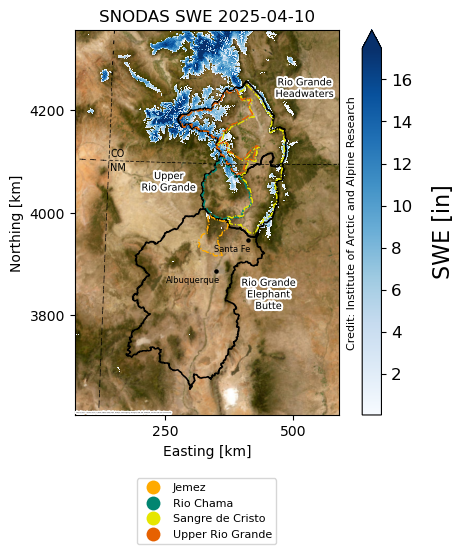

In [ ]:
bounds = huc6.total_bounds
xpad = 100000
ypad_top = 100000
ypad_bottom = 50000
bounds_padded = [bounds[0]-xpad, bounds[1]-ypad_bottom, bounds[2]+xpad, bounds[3]+ypad_top]
clipped_data = snodas_utm.where(snodas_utm>=0).rio.clip_box(*bounds_padded) / 1000 * 3.2808 * 12 # convert to inches
clipped_data = clipped_data.where(clipped_data != 0, np.nan)

## percentile for colorbar
perc_max = np.nanpercentile(clipped_data, 95)

## manually assign OSE colors
custom_colors = ["#FFAA00", "#018571", "#E6E600", "#E66101"]
custom_cmap = mcolors.ListedColormap(custom_colors)

# Plot
fig, ax = plt.subplots(figsize=(6,5))
clipped_data.plot(ax=ax, cmap='Blues', vmax = perc_max)
#clipped_data.plot(ax=ax, cmap='Blues')
cbar = ax.collections[-1].colorbar
cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)

# source = cx.providers.CartoDB.Positron
#source = cx.providers.Esri.WorldImagery
cx.add_basemap(ax, crs=clipped_data.rio.crs, source = cx.providers.Esri.WorldImagery, 
               attribution_size=0)
state_boundaries.plot(color = 'None',
                      edgecolor='black',
                      linewidth=0.5,
                      ax=ax,
                      linestyle=(0, (5, 10)))
## add state labels
dx_state = [-240000, 0, -295000, 0]
dy_state = [280000, 0, -200000, 0]
for idx, row in state_boundaries.iterrows():
    label_text = row["STUSPS"]
    if label_text in ["UT", "AZ"]:
        label_text = ""

    centroid = row.geometry.centroid
    ax.text(centroid.x + dx_state[idx], centroid.y + dy_state[idx], label_text, #row["Name"],
            fontsize=7, color="black", ha="center", va="center")

## add Albuquerque and Santa Fe
nm_cities.plot(ax=ax, marker='o', markersize=5, color='black')
dx_city = [-30000, -45000]
dy_city = [-17500, -17500]
for idx, row in nm_cities.iterrows():
    label_text = row["NAME"]
    centroid = row.geometry
    ax.text(centroid.x + dx_city[idx], centroid.y + dy_city[idx], label_text,
            fontsize=6, color="black", ha="center", va="center")

## add huc6 polygons
huc6.plot(color='None',
                    edgecolor='black',
                    linewidth=1.1,
                    ax=ax)

## add labels to HUC6 basins
dx = [125000, -145000, 150000]
dy = [80000, 25000, 0]
label_text = ['Rio Grande\nHeadwaters', 'Upper\nRio Grande', 
              'Rio Grande\nElephant\nButte']
for idx, row in huc6.iterrows():
    #label_text = row["Name"].replace(" ", "\n")

    centroid = row.geometry.centroid
    ax.text(centroid.x + dx[idx], centroid.y + dy[idx], label_text[idx], #row["Name"],
            fontsize=7, color="black", ha="center", va="center",
            path_effects=[PathEffects.withStroke(linewidth=3, foreground="white")])

## add OSE polygons
## dotted lines so overlapping boundaries are visible
OSE.plot(column='Name',  
         #cmap='turbo',
         cmap = custom_cmap,
         facecolor='none', 
         edgecolor=None, 
         linewidth=0.9,  
         legend=True,
         legend_kwds={'fontsize': 8},
         ax=ax,
         alpha=1,
         linestyle="-.")
         
# convert axes from m to km
m2km = lambda x, _: f'{x/1000:g}'
ax.xaxis.set_major_formatter(m2km)
ax.yaxis.set_major_formatter(m2km)
ax.locator_params(axis="x", nbins=2)
ax.locator_params(axis="y", nbins=4)
#ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
ax.set_xlabel('Easting [km]')
ax.set_ylabel('Northing [km]')
ax.set_title(f'SNODAS SWE {formatted_date}')
# add INSTAAR credit
ax.text(1.05, 0.5, 'Credit: Institute of Arctic and Alpine Research', rotation=90, 
        va='center', ha='center', transform=ax.transAxes, fontsize=8)
# change legend position
legend = ax.get_legend()
if legend:
    legend.set_bbox_to_anchor((0.5, -0.25)) # move legend below plot
    legend.set_loc("center")

#plt.show()
plt.savefig(f'../reports/{formatted_date}/figures/figure1_swe_{date}.png', dpi=300, bbox_inches='tight')

## HUC6 Basin Figures

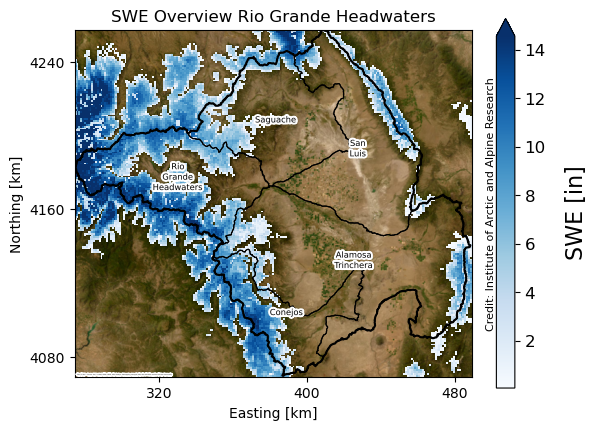

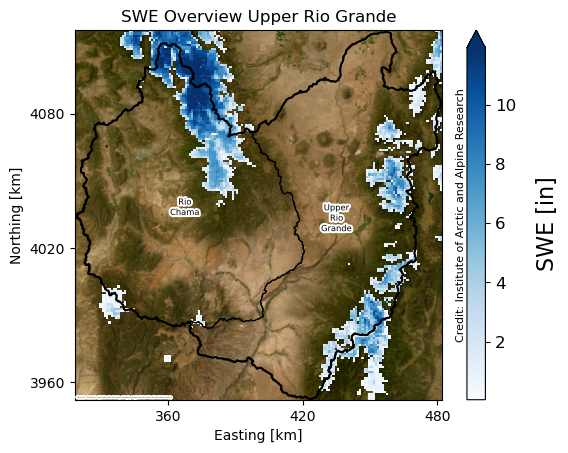

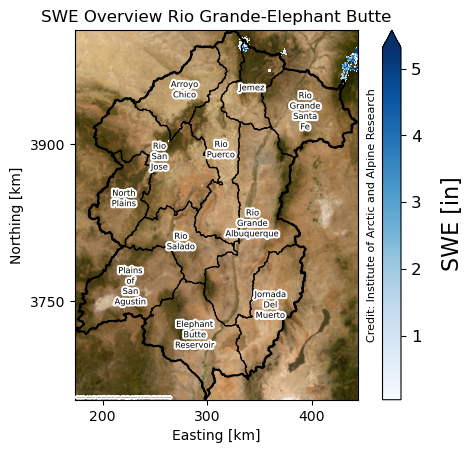

In [ ]:
for idx, basin in huc6.iterrows():
    bounds = basin.geometry.bounds
    swe_basin = clipped_data.where(clipped_data>=0).rio.clip_box(*bounds)
    ## percentile for colorbar
    perc_max = np.nanpercentile(swe_basin, 95)

    huc8_basins = huc8.loc[huc8['HUC6 Basin'] == basin['Name']]
    #print(huc8_basins)

    #swe_basin = clipped_data.rio.clip([basin.geometry])
        
    ## plot clipped polygon
    f, ax = plt.subplots()
    #swe_basin.plot(cmap="Blues", ax=ax)
    swe_basin.plot(ax=ax, cmap='Blues', vmax = perc_max)
    cbar = ax.collections[-1].colorbar
    cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
    cbar.ax.tick_params(labelsize=12)

    cx.add_basemap(ax, crs=clipped_data.rio.crs, source = cx.providers.Esri.WorldImagery, attribution_size=0)
    #cx.add_basemap(ax, crs=clipped_data.rio.crs)

    gpd.GeoSeries(basin.geometry).boundary.plot(ax=ax, edgecolor="black", linewidth=1.5)
    huc8_basins.plot(color='None',
                    edgecolor='black',
                    linewidth=0.8,
                    ax=ax)
    ## add huc8 polygon labels
    
    for idx, row in huc8_basins.iterrows():
        label_text = row["Name"].replace("-", " ")
        label_text = label_text.replace(" ", "\n")

        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, label_text, #row["Name"],
                fontsize=6, color="black", ha="center", va="center",
                path_effects=[PathEffects.withStroke(linewidth=3, foreground="white")])
                

    m2km = lambda x, _: f'{x/1000:g}'
    ax.xaxis.set_major_formatter(m2km)
    ax.yaxis.set_major_formatter(m2km)
    #ax.locator_params(axis="x", nbins=3)
    #ax.locator_params(axis="y", nbins=3)
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(3))
    plt.gca().yaxis.set_major_locator(plt.MaxNLocator(3))
    #ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
    ax.set_xlabel('Easting [km]')
    ax.set_ylabel('Northing [km]')
    ax.set_title('SWE Overview ' + basin['Name'])
    ax.text(1.05, 0.5, 'Credit: Institute of Arctic and Alpine Research', rotation=90, 
            va='center', ha='center', transform=ax.transAxes, fontsize=8)
    #plt.show()
    plt.savefig(f'../reports/{formatted_date}/figures/figure2_{basin['Name']}_{date}.png', dpi=300, bbox_inches='tight')

## Difference Plot

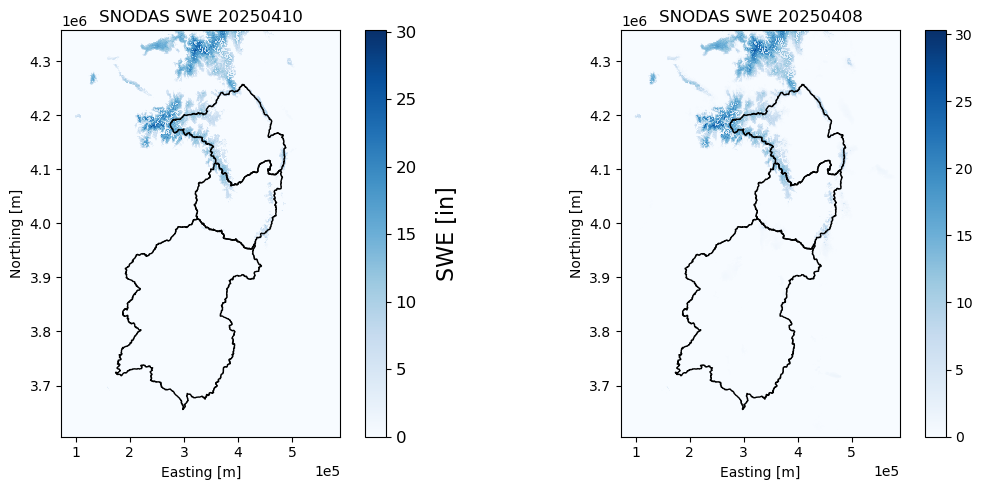

In [8]:
# Read data from last report date, reproject to UTM Zone 13N
snodas_last = rxr.open_rasterio(filename_lastreport).sel(band=1).reset_coords('band', drop=True)
snodas_utm_last = snodas_last.rio.reproject('epsg:26913', resolution=1000, resampling = 0) # 0=nearest neighbor
clipped_data_last = snodas_utm_last.where(snodas_utm_last>=0).rio.clip_box(*bounds_padded) / 1000 * 3.2808 * 12 # convert to inches
#clipped_data_last.where(clipped_data_last != 0, np.nan)
clipped_data = clipped_data.fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(11,5))
clipped_data.plot(ax=ax[0], cmap='Blues')
clipped_data_last.plot(ax=ax[1], cmap='Blues')
cbar = ax[0].collections[-1].colorbar
cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)
#huc8.plot(ax=ax[0], facecolor='none', edgecolor='k')
huc6.plot(ax=ax[0], facecolor='none', edgecolor = 'black')
#huc8.plot(ax=ax[0], facecolor='none', edgecolor='k')
huc6.plot(ax=ax[1], facecolor='none', edgecolor = 'black')
#huc6_viz.plot(ax=ax[0], facecolor='none', edgecolor='k')
#huc6_viz.plot(ax=ax[1], facecolor='none', edgecolor='k')
for axx in ax.flatten():
    axx.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
    axx.set_xlabel('Easting [m]')
    axx.set_ylabel('Northing [m]')
    #axx.set_title('SWE Difference')
ax[0].set_title(f"SNODAS SWE {date}")    
ax[1].set_title(f"SNODAS SWE {date_lastreport}")    
plt.tight_layout()

POINT (397631.1876357518 3807930.43330234)
POINT (-75680.97377810067 4372116.888473334)
POINT (452506.9410488482 4316655.993819575)
POINT (-114137.53380072539 3812891.7147224857)


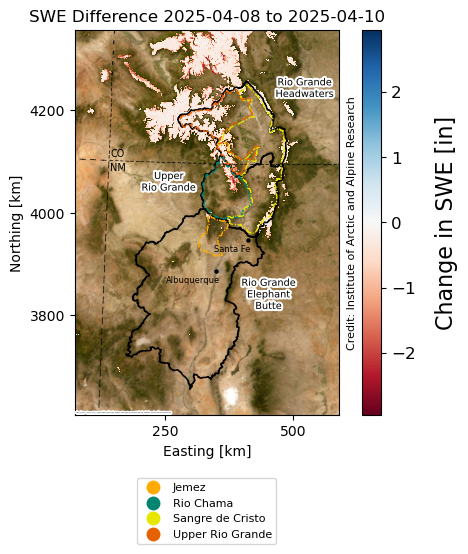

In [ ]:
## create difference raster
swe_diff = clipped_data - clipped_data_last
swe_diff = swe_diff.where(swe_diff != 0, np.nan)

## get min and max values for colorbar
swe_min = -np.nanmax(np.abs(swe_diff))
swe_max = np.nanmax(np.abs(swe_diff))


# Plot
fig, ax = plt.subplots(figsize=(6,5))
swe_diff.plot(ax=ax, cmap='RdBu', vmin = swe_min, vmax = swe_max)
cbar = ax.collections[-1].colorbar
cbar.set_label('Change in SWE [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)
cx.add_basemap(ax, crs=clipped_data.rio.crs, source = cx.providers.Esri.WorldImagery, 
               attribution_size=0)
state_boundaries.plot(color = 'None',
                      edgecolor='black',
                      linewidth=0.5,
                      ax=ax,
                      linestyle=(0, (5, 10)))
## add state labels
dx_state = [-240000, 0, -295000, 0]
dy_state = [280000, 0, -200000, 0]
for idx, row in state_boundaries.iterrows():
    label_text = row["STUSPS"]
    if label_text in ["UT", "AZ"]:
        label_text = ""

    centroid = row.geometry.centroid
    ax.text(centroid.x + dx_state[idx], centroid.y + dy_state[idx], label_text, #row["Name"],
            fontsize=7, color="black", ha="center", va="center")
    
## add Albuquerque and Santa Fe
nm_cities.plot(ax=ax, marker='o', markersize=5, color='black')
dx_city = [-30000, -45000]
dy_city = [-17500, -17500]
#label_text = ['Santa Fe', 'ABQ']
for idx, row in nm_cities.iterrows():
    label_text = row["NAME"]

    centroid = row.geometry
    ax.text(centroid.x + dx_city[idx], centroid.y + dy_city[idx], label_text,
            fontsize=6, color="black", ha="center", va="center")

#cx.add_basemap(ax, crs=clipped_data.rio.crs)
## add huc6 polygons
huc6.plot(color='None',
                    edgecolor='black',
                    linewidth=1.1,
                    ax=ax)

## add polygon labels
dx = [125000, -145000, 150000]
dy = [80000, 25000, 0]
label_text = ['Rio Grande\nHeadwaters', 'Upper\nRio Grande', 
              'Rio Grande\nElephant\nButte']
for idx, row in huc6.iterrows():
    #label_text = row["Name"].replace(" ", "\n")

    centroid = row.geometry.centroid
    ax.text(centroid.x + dx[idx], centroid.y + dy[idx], label_text[idx], #row["Name"],
            fontsize=7, color="black", ha="center", va="center",
            path_effects=[PathEffects.withStroke(linewidth=3, foreground="white")])

## plot with outlined polygons
## dotted lines so overlapping boundaries are visible

OSE.plot(column='Name',  
         #cmap='turbo',
         cmap = custom_cmap,
         facecolor='none', 
         edgecolor=None, 
         linewidth=0.9,  
         legend=True,
         legend_kwds={'fontsize': 8},
         ax=ax,
         alpha=1,
         linestyle="-.")
         

m2km = lambda x, _: f'{x/1000:g}'
ax.xaxis.set_major_formatter(m2km)
ax.yaxis.set_major_formatter(m2km)
ax.locator_params(axis="x", nbins=2)
ax.locator_params(axis="y", nbins=4)
#ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
ax.set_xlabel('Easting [km]')
ax.set_ylabel('Northing [km]')
ax.set_title(f'SWE Difference {formatted_date_lastreport} to {formatted_date}')

ax.text(1.05, 0.5, 'Credit: Institute of Arctic and Alpine Research', rotation=90, 
        va='center', ha='center', transform=ax.transAxes, fontsize=8)

legend = ax.get_legend()
if legend:
    legend.set_bbox_to_anchor((0.5, -0.25)) # move legend below plot
    legend.set_loc("center")

#plt.show()
plt.savefig(f'../reports/{formatted_date}/figures/figure1_swe_diff_{date}.png', dpi=300, bbox_inches='tight')

## SWE Change HUC6

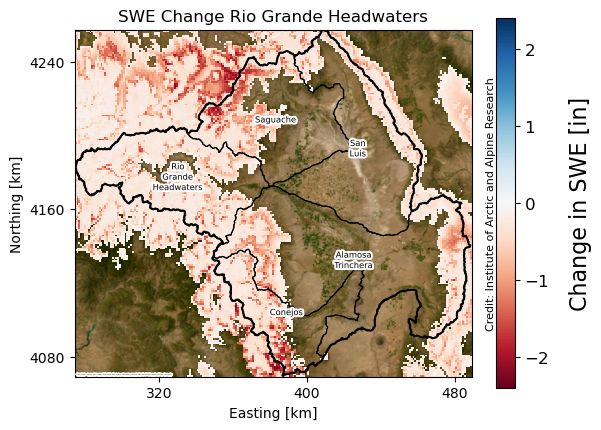

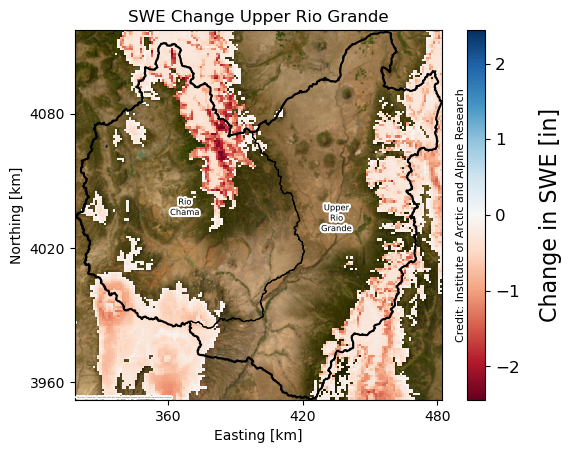

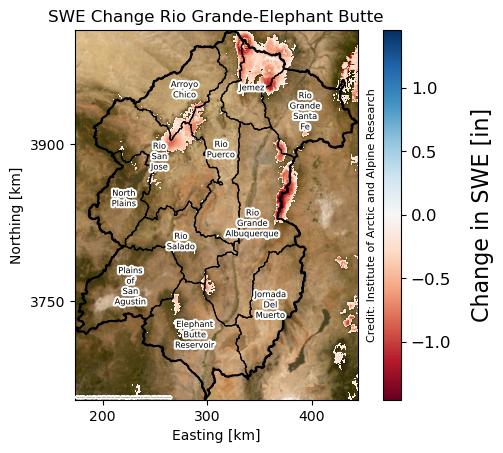

In [20]:
for idx, basin in huc6.iterrows():
    # clip raster to basin bounds
    bounds = basin.geometry.bounds
    swe_basin = clipped_data.where(clipped_data>=0).rio.clip_box(*bounds)
    swe_basin_last = clipped_data_last.where(clipped_data_last>=0).rio.clip_box(*bounds) # clip data from last report

    # calculate SWE difference for basin
    swe_basin_diff = swe_basin - swe_basin_last
    swe_basin_diff = swe_basin_diff.where(swe_basin_diff != 0, np.nan)
    
    # get min and max for colorbar
    swe_min = -np.nanmax(np.abs(swe_basin_diff))
    swe_max = np.nanmax(np.abs(swe_basin_diff))
    
    huc8_basins = huc8.loc[huc8['HUC6 Basin'] == basin['Name']]
    #print(huc8_basins)

    #swe_basin = clipped_data.rio.clip([basin.geometry])
        
    ## plot clipped polygon
    f, ax = plt.subplots()
    #swe_basin.plot(cmap="Blues", ax=ax)
    swe_basin_diff.plot(ax=ax, cmap='RdBu', vmin=swe_min, vmax=swe_max)
    cbar = ax.collections[-1].colorbar
    cbar.set_label('Change in SWE [in]', fontsize=16, labelpad=14)
    cbar.ax.tick_params(labelsize=12)

    cx.add_basemap(ax, crs=clipped_data.rio.crs, source = cx.providers.Esri.WorldImagery, attribution_size=0)
    #cx.add_basemap(ax, crs=clipped_data.rio.crs)

    gpd.GeoSeries(basin.geometry).boundary.plot(ax=ax, edgecolor="black", linewidth=1.5)
    huc8_basins.plot(color='None',
                    edgecolor='black',
                    linewidth=0.8,
                    ax=ax)
    ## add huc8 polygon labels
    
    for idx, row in huc8_basins.iterrows():
        label_text = row["Name"].replace("-", " ")
        label_text = label_text.replace(" ", "\n")

        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, label_text, #row["Name"],
                fontsize=6, color="black", ha="center", va="center",
                path_effects=[PathEffects.withStroke(linewidth=3, foreground="white")])
                

    m2km = lambda x, _: f'{x/1000:g}'
    ax.xaxis.set_major_formatter(m2km)
    ax.yaxis.set_major_formatter(m2km)
    #ax.locator_params(axis="x", nbins=3)
    #ax.locator_params(axis="y", nbins=3)
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(3))
    plt.gca().yaxis.set_major_locator(plt.MaxNLocator(3))
    #ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
    ax.set_xlabel('Easting [km]')
    ax.set_ylabel('Northing [km]')
    ax.set_title('SWE Change ' + basin['Name'])
    ax.text(1.05, 0.5, 'Credit: Institute of Arctic and Alpine Research', rotation=90, 
            va='center', ha='center', transform=ax.transAxes, fontsize=8)
    #plt.show()
    plt.savefig(f'../reports/{formatted_date}/figures/figure2_diff_{basin['Name']}_{date}.png', dpi=300, bbox_inches='tight')